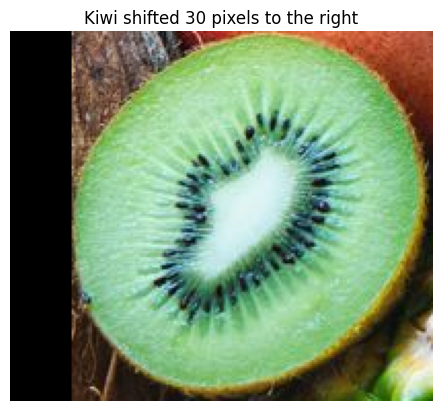

In [14]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as nd

# Load the image
data = iio.imread('exercise/colorful-ripe-tropical-fruits.jpg')

kiwi = data[920:1100, 394:600]  # Example values; change them after testing

# Shift the kiwi 30 pixels to the right (down, right)
shifted_kiwi = nd.shift(kiwi, shift=(0, 30, 0))  # (row, column, channel)

# Display the result
plt.imshow(shifted_kiwi)
plt.axis('off')
plt.title("Kiwi shifted 30 pixels to the right")
plt.show()


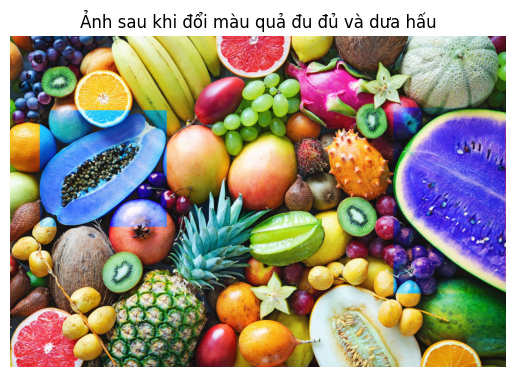

In [22]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

# Đọc ảnh từ thư mục
img = iio.imread('exercise/colorful-ripe-tropical-fruits.jpg')

# Cắt vùng chứa quả đu đủ và quả dưa hấu (cần chỉnh lại theo ảnh thực tế)
# Dạng: img[y1:y2, x1:x2]
du_du = img[317:815, 127:670].copy()       # ví dụ: vùng quả đu đủ
dua_hau = img[305:1100, 1638:2117].copy()     # ví dụ: vùng quả dưa hấu

# Hàm đổi màu bằng cách đảo kênh màu RGB -> BGR
def doi_mau(vung_anh):
    return vung_anh[..., [2, 1, 0]]

# Áp dụng đổi màu và chèn lại vào ảnh gốc
img[317:815, 127:670] = doi_mau(du_du)
img[305:1100, 1638:2117] = doi_mau(dua_hau)

# Hiển thị ảnh kết quả
plt.imshow(img)
plt.axis('off')
plt.title("Ảnh sau khi đổi màu quả đu đủ và dưa hấu")
plt.show()


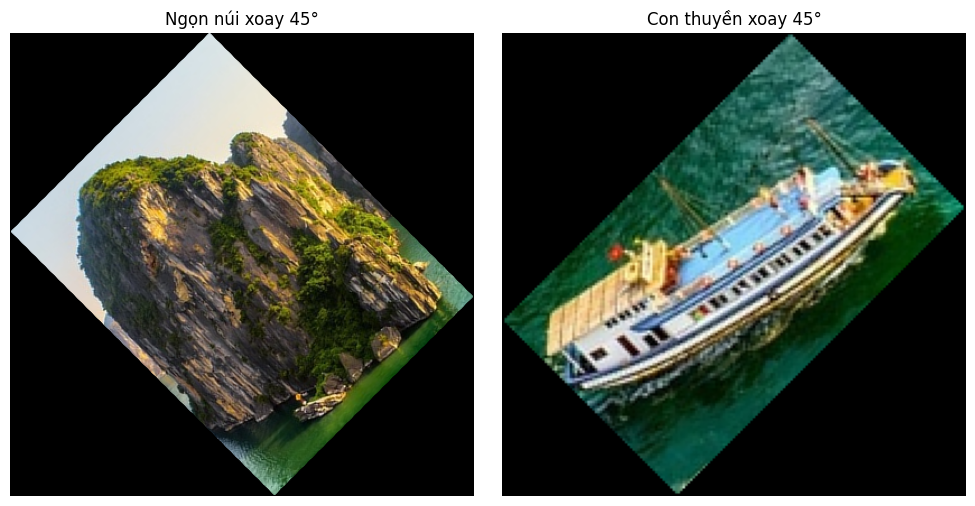

In [3]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as nd

# Đọc ảnh gốc
img = iio.imread('exercise/quang_ninh.jpg')

# === 1. Cắt ngọn núi và con thuyền bằng slicing ===
# Bạn có thể chỉnh tọa độ cho phù hợp ảnh của bạn

# Ví dụ: [y1:y2, x1:x2]
mountain = img[8:342, 422:674, :]    # Cắt ngọn núi
boat = img[453:552, 495:658, :]        # Cắt con thuyền

# === 2. Xoay 45 độ mỗi đối tượng ===
rotated_mountain = nd.rotate(mountain, angle=45, reshape=True)
rotated_boat = nd.rotate(boat, angle=45, reshape=True)

# === 3. Hiển thị kết quả và lưu ===
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(rotated_mountain)
axs[0].set_title("Ngọn núi xoay 45°")
axs[0].axis('off')

axs[1].imshow(rotated_boat)
axs[1].set_title("Con thuyền xoay 45°")
axs[1].axis('off')

plt.tight_layout()
plt.savefig("rotated_mountain_boat.jpg")
plt.show()


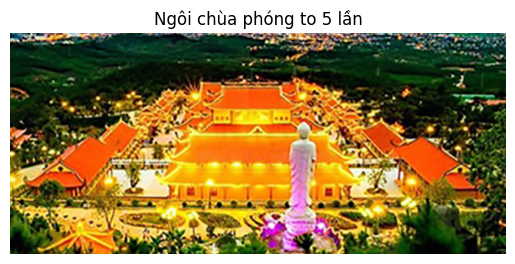

In [4]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as nd

# Bước 1: Đọc ảnh gốc
img = iio.imread('exercise/pagoda.jpg')

# Bước 2: Cắt vùng có ngôi chùa (có thể chỉnh tùy ảnh bạn)
# Ví dụ: [y1:y2, x1:x2]
pagoda = img[87:304, 33:519, :]  # Cắt vùng ngôi chùa

# Bước 3: Phóng to ngôi chùa gấp 5 lần
zoomed_pagoda = nd.zoom(pagoda, zoom=(5, 5, 1), order=1)

# Bước 4: Lưu ảnh
iio.imwrite('pagoda_zoomed.jpg', zoomed_pagoda)

# Hiển thị kết quả
plt.imshow(zoomed_pagoda)
plt.title("Ngôi chùa phóng to 5 lần")
plt.axis('off')
plt.show()


MENU:
T - Tịnh tiến
X - Xoay
P - Phóng to
H - Thu nhỏ
C - Coordinate Map
Chọn hình 3


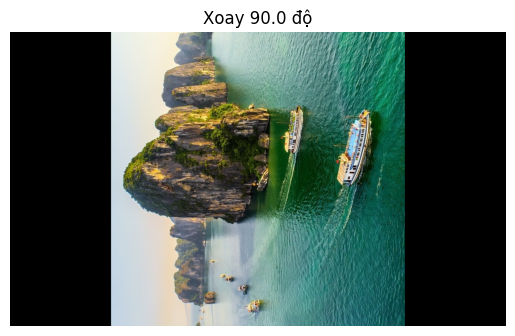

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
from scipy import ndimage as nd

def load_image():
    choice = input("Nhập số hình (1-3): ")
    if choice == '1':
        print("Chọn hình 1")
        return iio.imread('exercise/pagoda.jpg')
    
    elif choice == '2':
        print("Chọn hình 2")
        return iio.imread('exercise/ha-long-bay-in-vietnam.jpg')
    elif choice == '3':
        print("Chọn hình 3")
        return iio.imread('exercise/quang_ninh.jpg')
    else:
        print("Lựa chọn không hợp lệ.")
        return None

def translate(img):
    dx = int(input("Nhập số pixel dịch theo trục x: "))
    dy = int(input("Nhập số pixel dịch theo trục y: "))
    shifted = nd.shift(img, shift=(dy, dx, 0))
    plt.imshow(shifted)
    plt.title(f"Tịnh tiến ({dx},{dy})")
    plt.axis('off')
    plt.show()

def rotate(img):
    angle = float(input("Nhập góc xoay: "))
    reshape = input("Có reshape không? (y/n): ").lower() == 'y'
    rotated = nd.rotate(img, angle=angle, reshape=reshape)
    plt.imshow(rotated)
    plt.title(f"Xoay {angle} độ")
    plt.axis('off')
    plt.show()

def zoom(img, factor):
    zoomed = nd.zoom(img, zoom=(factor, factor, 1))
    plt.imshow(zoomed)
    plt.title(f"Zoom x{factor}")
    plt.axis('off')
    plt.show()

def coordinate_map(img):
    def wave(coords):
        coords[0] += 20 * np.sin(coords[1] / 50.0)
        return coords

    warped = np.zeros_like(img)
    for c in range(3):  # RGB
        warped[..., c] = nd.geometric_transform(img[..., c], wave, order=1)
    plt.imshow(warped)
    plt.title("Biến đổi tọa độ (Wave)")
    plt.axis('off')
    plt.show()

# ========== Giao diện chính ==========
print("MENU:")
print("T - Tịnh tiến")
print("X - Xoay")
print("P - Phóng to")
print("H - Thu nhỏ")
print("C - Coordinate Map")

option = input("Nhập lựa chọn (T/X/P/H/C): ").upper()
img = load_image()

if img is not None:
    if option == 'T':
        translate(img)
    elif option == 'X':
        rotate(img)
    elif option == 'P':
        zoom(img, factor=2)
    elif option == 'H':
        zoom(img, factor=0.5)
    elif option == 'C':
        coordinate_map(img)
    else:
        print("Lựa chọn không hợp lệ.")
